In [2]:
import pandas as pd
import numpy as np

# Load datasets
movies_metadata = pd.read_csv('movies_metadata.csv', dtype={'id': 'str'}, low_memory=False)
keywords = pd.read_csv('keywords.csv', dtype={'id': 'str'})
links = pd.read_csv('links.csv', dtype={'movieId': 'str', 'tmdbId': 'str', 'imdbId': 'str'})

# Normalize ID columns
movies_metadata['id'] = movies_metadata['id'].str.zfill(6)
links['tmdbId'] = links['tmdbId'].str.zfill(6)

# Merge keywords.csv to add keywords information
movies_metadata = movies_metadata.merge(keywords, left_on='id', right_on='id', how='left')

# Merge with links.csv to add tmdbId and imdbId where missing
movies_metadata = movies_metadata.merge(links, left_on='id', right_on='tmdbId', how='left')

# Fill missing imdbId and tmdbId using links.csv
movies_metadata['imdb_id'] = movies_metadata['imdb_id'].fillna(movies_metadata['imdbId'])
movies_metadata['id'] = movies_metadata['id'].fillna(movies_metadata['tmdbId'])

# Convert budget, revenue, and runtime to numeric, coercing errors to NaN
for col in ['budget', 'revenue', 'runtime']:
    movies_metadata[col] = pd.to_numeric(movies_metadata[col], errors='coerce')

# Fill missing values for budget, revenue, and runtime with median values grouped by genres
for col in ['budget', 'revenue', 'runtime']:
    movies_metadata[col] = movies_metadata.groupby('genres')[col].transform(lambda x: x.fillna(x.median()))

# Fill missing keywords with "[]"
movies_metadata['keywords'] = movies_metadata['keywords'].fillna('[]')

# Fill missing values for categorical columns with "Unknown"
categorical_columns = ['original_language', 'overview', 'title']
for col in categorical_columns:
    movies_metadata[col] = movies_metadata[col].fillna('Unknown')

# Function to convert genres to the desired format
def convert_genres(genres_list):
    if isinstance(genres_list, str):  # Check if the value is a string
        try:
            genres = eval(genres_list)  # Safely evaluate the string to a Python list
        except (SyntaxError, NameError):
            genres = []  # Handle improper formats
    elif isinstance(genres_list, list):  # Check if the value is already a list
        genres = genres_list
    else:
        genres = []

    # Extract 'name' field from each genre dictionary
    return "|".join(genre.get('name', '') for genre in genres if isinstance(genre, dict))

# Apply the conversion to the genres column for every row
movies_metadata['genres'] = movies_metadata['genres'].apply(convert_genres)

# Drop unnecessary columns
movies_metadata.drop(columns=['adult', 'belongs_to_collection', 'tagline', 'status', 'homepage', 'poster_path', 'video'], inplace=True)

# Reorder columns to provide a more logical sequence
ordered_columns = [
    'id', 'title', 'original_language', 'genres', 'release_date', 'overview',
    'budget', 'revenue', 'runtime', 'vote_average', 'vote_count',
    'imdb_id', 'movieId', 'imdbId', 'tmdbId', 'production_companies', 'production_countries',
    'spoken_languages', 'popularity'
]
movies_metadata = movies_metadata[[col for col in ordered_columns if col in movies_metadata.columns]]

# Count of valid values and missing values (including NaN, empty strings, and zeros) for each column
def count_values(df):
    for col in df.columns:
        valid_count = df[col].notna().sum() - (df[col] == 0).sum() - (df[col] == '').sum()
        missing_count = df[col].isna().sum() + (df[col] == 0).sum() + (df[col] == '').sum()
        print(f"{col}: {valid_count} with a value, {missing_count} missing or zero values")

count_values(movies_metadata)

# Save the cleaned data to a new CSV file
movies_metadata.to_csv('complete_movies_metadata.csv', index=False)


id: 46170 with a value, 0 missing or zero values
title: 46170 with a value, 0 missing or zero values
original_language: 46170 with a value, 0 missing or zero values
genres: 43671 with a value, 2499 missing or zero values
release_date: 46082 with a value, 88 missing or zero values
overview: 46170 with a value, 0 missing or zero values
budget: 8995 with a value, 37175 missing or zero values
revenue: 7498 with a value, 38672 missing or zero values
runtime: 44554 with a value, 1616 missing or zero values
vote_average: 43073 with a value, 3097 missing or zero values
vote_count: 43173 with a value, 2997 missing or zero values
imdb_id: 46170 with a value, 0 missing or zero values
movieId: 46167 with a value, 3 missing or zero values
imdbId: 46167 with a value, 3 missing or zero values
tmdbId: 46167 with a value, 3 missing or zero values
production_companies: 46166 with a value, 4 missing or zero values
production_countries: 46166 with a value, 4 missing or zero values
spoken_languages: 46163 

In [3]:
import pandas as pd
import numpy as np

complete_movies_metadata = pd.read_csv('complete_movies_metadata.csv', low_memory=False)
merged_movie_ratings = pd.read_csv('merge_movie_ratings.csv', low_memory=False)

# Distribution of Movies by Provider
complete_movies_metadata['production_companies'] = complete_movies_metadata['production_companies'].fillna('[]')
complete_movies_metadata['production_companies'] = complete_movies_metadata['production_companies'].apply(eval)
complete_movies_metadata['provider'] = complete_movies_metadata['production_companies'].apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])

# Explode providers into separate rows
movies_with_providers = complete_movies_metadata[['id', 'provider']].explode('provider')
provider_distribution = movies_with_providers['provider'].value_counts()
print("Distribution of Movies by Provider:")
print(provider_distribution)

# Distribution of Movie Ratings by Provider
movies_with_providers['id'] = movies_with_providers['id'].astype(str)
merged_movie_ratings['movieId'] = merged_movie_ratings['movieId'].astype(str)

# Merging ratings with providers information
ratings_with_providers = merged_movie_ratings.merge(movies_with_providers, left_on='movieId', right_on='id', how='left')
ratings_by_provider = ratings_with_providers.groupby('provider')['rating'].count()
print("\nDistribution of Movie Ratings by Provider:")
print(ratings_by_provider)

# Distribution of Movies by Country and Language
complete_movies_metadata['production_countries'] = complete_movies_metadata['production_countries'].fillna('[]').apply(eval)
complete_movies_metadata['spoken_languages'] = complete_movies_metadata['spoken_languages'].fillna('[]').apply(eval)

movies_with_countries = complete_movies_metadata[['id', 'production_countries']].explode('production_countries')
movies_with_languages = complete_movies_metadata[['id', 'spoken_languages']].explode('spoken_languages')

movies_with_countries['country'] = movies_with_countries['production_countries'].apply(lambda x: x['name'] if isinstance(x, dict) else None)
movies_with_languages['language'] = movies_with_languages['spoken_languages'].apply(lambda x: x['name'] if isinstance(x, dict) else None)

# Distribution by Country
country_distribution = movies_with_countries['country'].value_counts()
print("\nDistribution of Movies by Country:")
print(country_distribution)

# Distribution by Language
language_distribution = movies_with_languages['language'].value_counts()
print("\nDistribution of Movies by Language:")
print(language_distribution)


Distribution of Movies by Provider:
provider
Warner Bros.                              1252
Metro-Goldwyn-Mayer (MGM)                 1092
Paramount Pictures                        1011
Twentieth Century Fox Film Corporation     840
Universal Pictures                         833
                                          ... 
Desert Flower Filmproductions                1
Desert Flower                                1
3rd Vision Films                             1
Atrium Productions                           1
Yermoliev                                    1
Name: count, Length: 23537, dtype: int64

Distribution of Movie Ratings by Provider:
provider
ABC Pictures                              2
Apaches Entertainment                     2
Art Theatre Guild                        11
Asatsu-DK                                 1
Asylum, The                               8
                                         ..
Yoshidamasaki                             1
ZRF "Syrena"                        

In [4]:
import pandas as pd

merged_movies = pd.read_csv('complete_movies_metadata.csv', low_memory=False)

# Analysis for genres
genres_distribution = merged_movies['genres'].value_counts()
print("Top 5 Genres by Movie Count:")
print(genres_distribution.head(5))
print("\nBottom 5 Genres by Movie Count:")
print(genres_distribution.tail(5))

# Analysis for release years
merged_movies['release_year'] = pd.to_datetime(merged_movies['release_date'], errors='coerce').dt.year
year_distribution = merged_movies['release_year'].value_counts()
print("\nTop 5 Years by Movie Count:")
print(year_distribution.head(5))
print("\nBottom 5 Years by Movie Count:")
print(year_distribution.tail(5))

# Analysis for budget
budget_sorted = merged_movies[['title', 'budget']].sort_values(by='budget', ascending=False).dropna()
print("\nTop 5 Movies by Budget:")
print(budget_sorted.head(5))
print("\nBottom 5 Movies by Budget:")
print(budget_sorted.tail(5))

# Analysis for revenue
revenue_sorted = merged_movies[['title', 'revenue']].sort_values(by='revenue', ascending=False).dropna()
print("\nTop 5 Movies by Revenue:")
print(revenue_sorted.head(5))
print("\nBottom 5 Movies by Revenue:")
print(revenue_sorted.tail(5))

# Analysis for runtime
runtime_sorted = merged_movies[['title', 'runtime']].sort_values(by='runtime', ascending=False).dropna()
print("\nTop 5 Movies by Runtime:")
print(runtime_sorted.head(5))
print("\nBottom 5 Movies by Runtime:")
print(runtime_sorted.tail(5))

# Analysis for vote_average
vote_average_sorted = merged_movies[['title', 'vote_average']].sort_values(by='vote_average', ascending=False).dropna()
print("\nTop 5 Movies by Average Vote:")
print(vote_average_sorted.head(5))
print("\nBottom 5 Movies by Average Vote:")
print(vote_average_sorted.tail(5))

# Analysis for vote_count
vote_count_sorted = merged_movies[['title', 'vote_count']].sort_values(by='vote_count', ascending=False).dropna()
print("\nTop 5 Movies by Vote Count:")
print(vote_count_sorted.head(5))
print("\nBottom 5 Movies by Vote Count:")
print(vote_count_sorted.tail(5))

# Analysis for popularity
popularity_sorted = merged_movies[['title', 'popularity']].sort_values(by='popularity', ascending=False).dropna()
print("\nTop 5 Movies by Popularity:")
print(popularity_sorted.head(5))
print("\nBottom 5 Movies by Popularity:")
print(popularity_sorted.tail(5))

# Analysis for production_countries
merged_movies['production_countries'] = merged_movies['production_countries'].fillna('[]').apply(eval)
merged_movies['country'] = merged_movies['production_countries'].apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])
movies_with_countries = merged_movies[['id', 'country']].explode('country')
country_distribution = movies_with_countries['country'].value_counts()
print("\nTop 5 Countries by Movie Count:")
print(country_distribution.head(5))
print("\nBottom 5 Countries by Movie Count:")
print(country_distribution.tail(5))

# Analysis for spoken_languages
merged_movies['spoken_languages'] = merged_movies['spoken_languages'].fillna('[]').apply(eval)
merged_movies['language'] = merged_movies['spoken_languages'].apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])
movies_with_languages = merged_movies[['id', 'language']].explode('language')
language_distribution = movies_with_languages['language'].value_counts()
print("\nTop 5 Languages by Movie Count:")
print(language_distribution.head(5))
print("\nBottom 5 Languages by Movie Count:")
print(language_distribution.tail(5))


Top 5 Genres by Movie Count:
genres
Drama            5096
Comedy           3662
Documentary      2798
Drama|Romance    1319
Comedy|Drama     1152
Name: count, dtype: int64

Bottom 5 Genres by Movie Count:
genres
TV Movie|Animation|Family|Comedy           1
Fantasy|Documentary|Animation|Drama        1
Fantasy|Mystery|Romance                    1
Animation|Action|Family|Science Fiction    1
Family|Animation|Romance|Comedy            1
Name: count, dtype: int64

Top 5 Years by Movie Count:
release_year
2014.0    2057
2015.0    2046
2013.0    1951
2012.0    1776
2011.0    1682
Name: count, dtype: int64

Bottom 5 Years by Movie Count:
release_year
2020.0    1
1887.0    1
1878.0    1
1874.0    1
1883.0    1
Name: count, dtype: int64

Top 5 Movies by Budget:
                                             title       budget
17193  Pirates of the Caribbean: On Stranger Tides  380000000.0
11856     Pirates of the Caribbean: At World's End  300000000.0
26654                      Avengers: Age of Ul

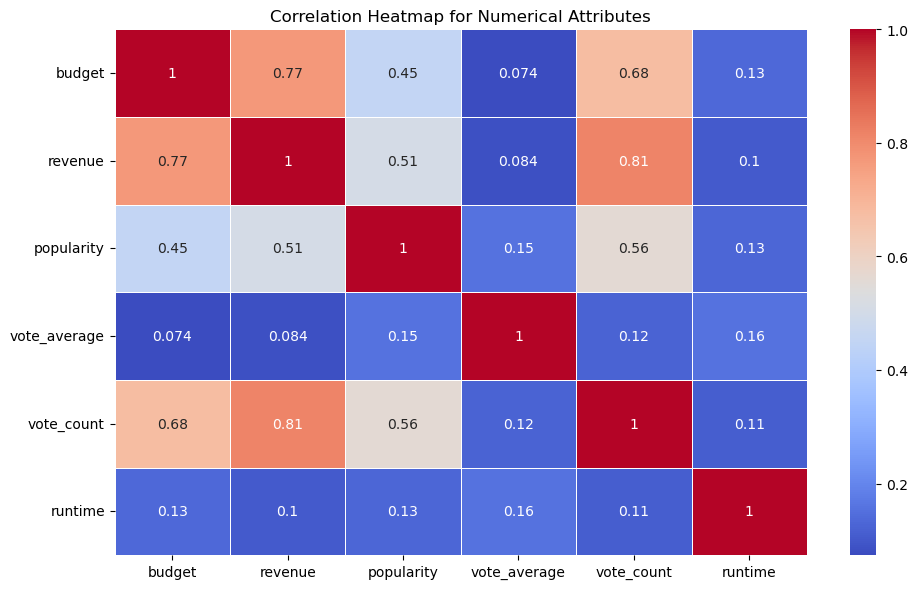

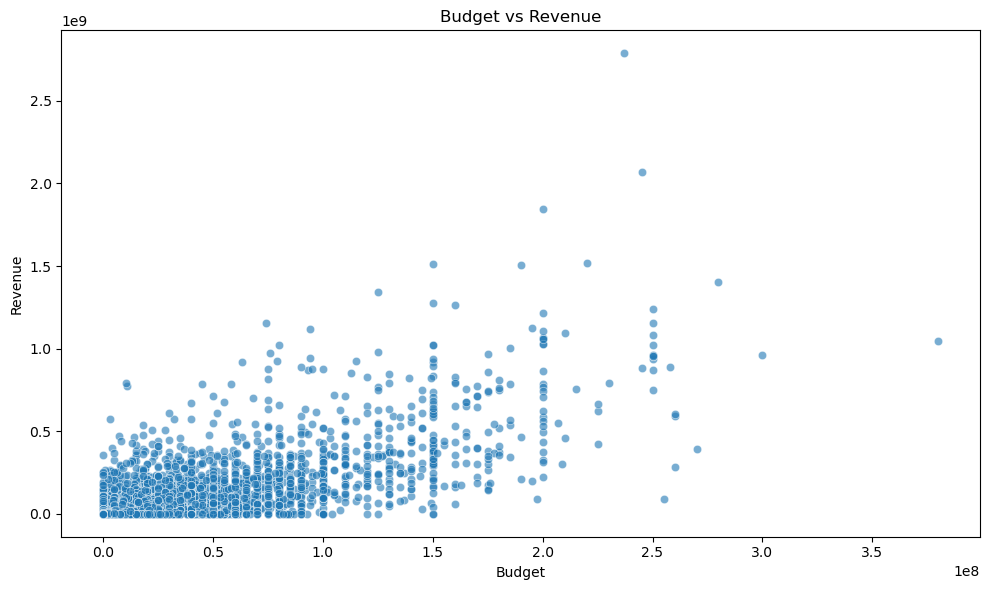

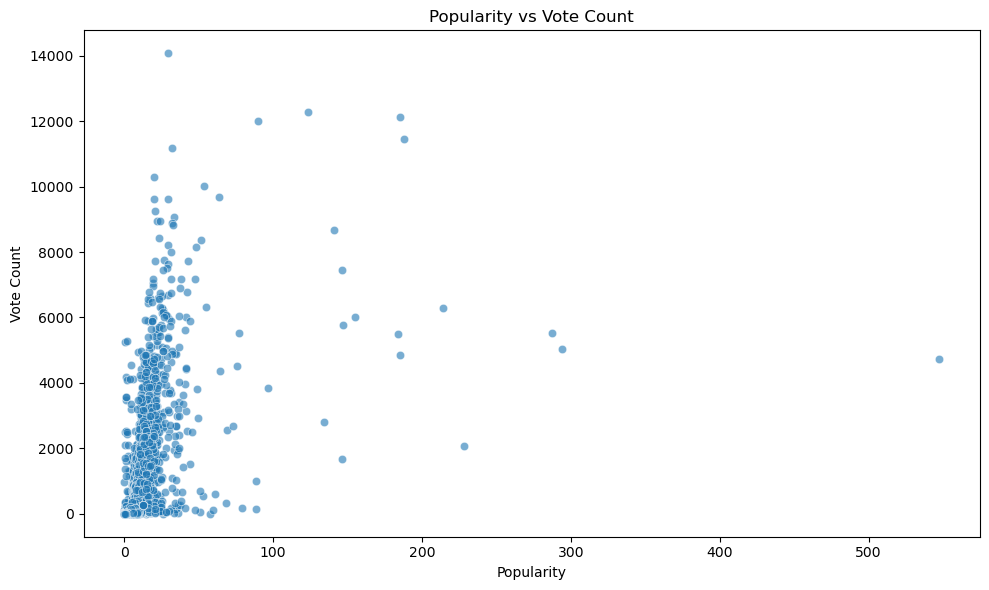

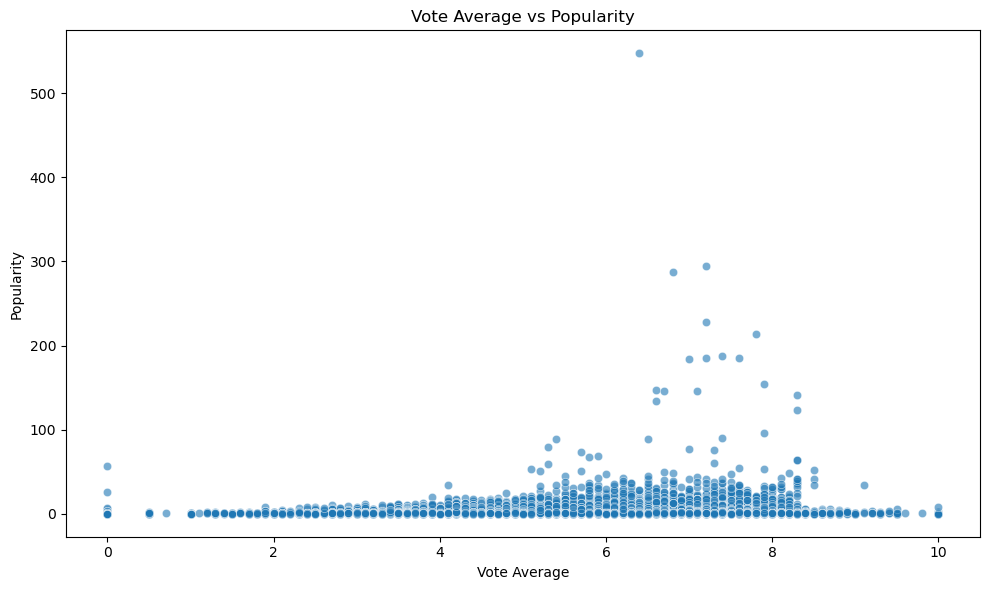

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

movies_metadata = pd.read_csv('complete_movies_metadata.csv', low_memory=False)

# Convert relevant columns to numeric values
for col in ['budget', 'revenue', 'popularity', 'vote_average', 'vote_count']:
    movies_metadata[col] = pd.to_numeric(movies_metadata[col], errors='coerce')

# Select columns relevant for correlation analysis
numerical_columns = ['budget', 'revenue', 'popularity', 'vote_average', 'vote_count', 'runtime']
correlation_data = movies_metadata[numerical_columns]

# Drop rows with missing values for these columns
correlation_data = correlation_data.dropna()

# Compute the correlation matrix
correlation_matrix = correlation_data.corr()

# Visualization: Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, linecolor='white')
plt.title('Correlation Heatmap for Numerical Attributes')
plt.tight_layout()
plt.show()

#  Budget vs Revenue
plt.figure(figsize=(10, 6))
sns.scatterplot(data=correlation_data, x='budget', y='revenue', alpha=0.6)
plt.title('Budget vs Revenue')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# Popularity vs Vote Count
plt.figure(figsize=(10, 6))
sns.scatterplot(data=correlation_data, x='popularity', y='vote_count', alpha=0.6)
plt.title('Popularity vs Vote Count')
plt.xlabel('Popularity')
plt.ylabel('Vote Count')
plt.tight_layout()
plt.show()

# Vote Average vs Popularity
plt.figure(figsize=(10, 6))
sns.scatterplot(data=correlation_data, x='vote_average', y='popularity', alpha=0.6)
plt.title('Vote Average vs Popularity')
plt.xlabel('Vote Average')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()


provider
Warner Bros.                              1252
Metro-Goldwyn-Mayer (MGM)                 1092
Paramount Pictures                        1011
Twentieth Century Fox Film Corporation     840
Universal Pictures                         833
                                          ... 
Desert Flower Filmproductions                1
Desert Flower                                1
3rd Vision Films                             1
Atrium Productions                           1
Yermoliev                                    1
Name: count, Length: 23537, dtype: int64


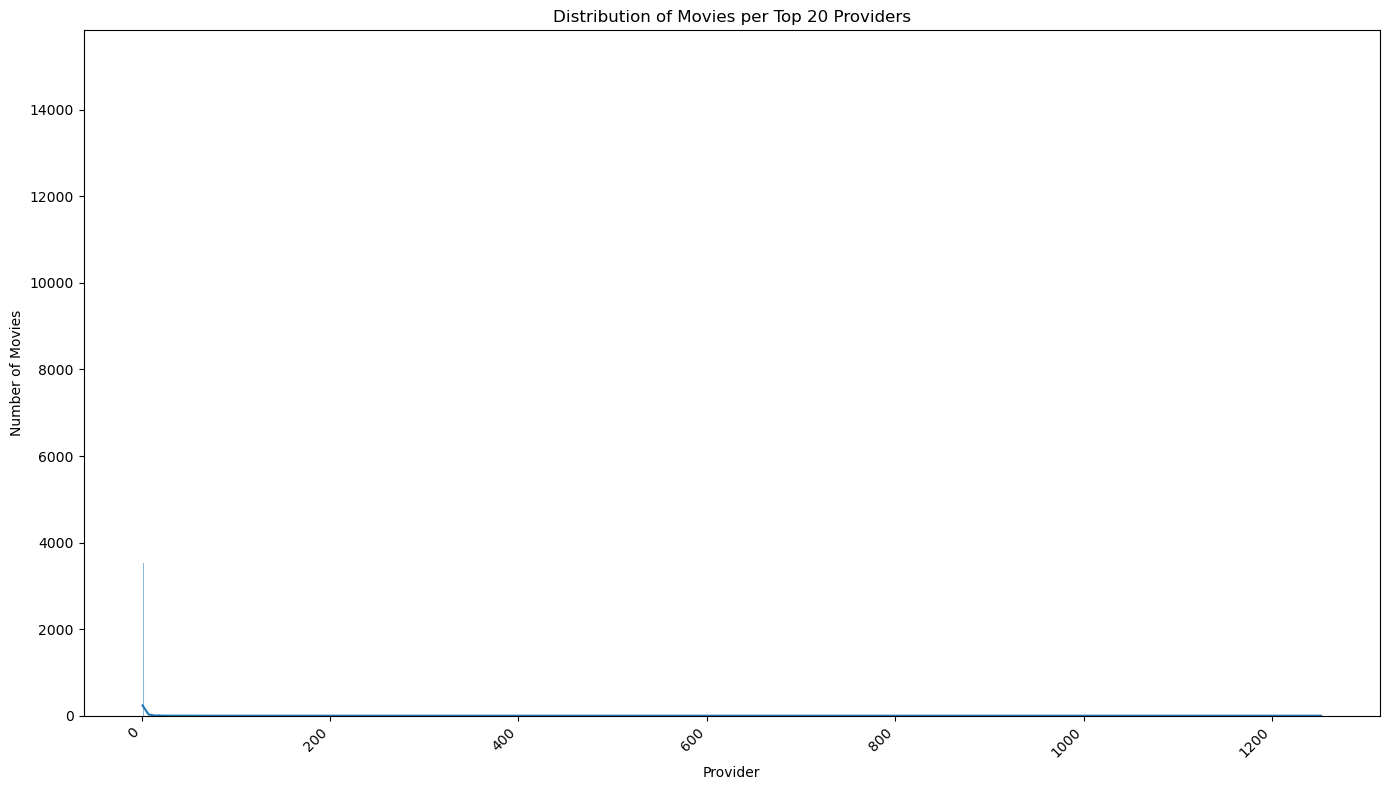

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

complete_movies_metadata = pd.read_csv('complete_movies_metadata.csv', low_memory=False)

# Extracting production companies information
complete_movies_metadata['production_companies'] = complete_movies_metadata['production_companies'].fillna('[]').apply(eval)
complete_movies_metadata['provider'] = complete_movies_metadata['production_companies'].apply(lambda x: [i['name'] for i in x] if isinstance(x, list) else [])

# Explode providers into separate rows
movies_with_providers = complete_movies_metadata[['id', 'provider']].explode('provider')

# Count the number of movies per provider
provider_distribution = movies_with_providers['provider'].value_counts()
print(provider_distribution)

# Select top 20 providers to make the graph more readable
top_20_providers = provider_distribution.head(20)

plt.figure(figsize=(14, 8))
sns.histplot(data=provider_distribution, kde=True)
plt.title('Distribution of Movies per Top 20 Providers')
plt.xlabel('Provider')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [7]:
new_df = provider_distribution.reset_index()
new_df.head()
# sns.barplot(new_df, x="provider", y="count")

,provider,count
0,Warner Bros.,1252
1,Metro-Goldwyn-Mayer (MGM),1092
2,Paramount Pictures,1011
3,Twentieth Century Fox Film Corporation,840
4,Universal Pictures,833


<Axes: xlabel='count', ylabel='Count'>

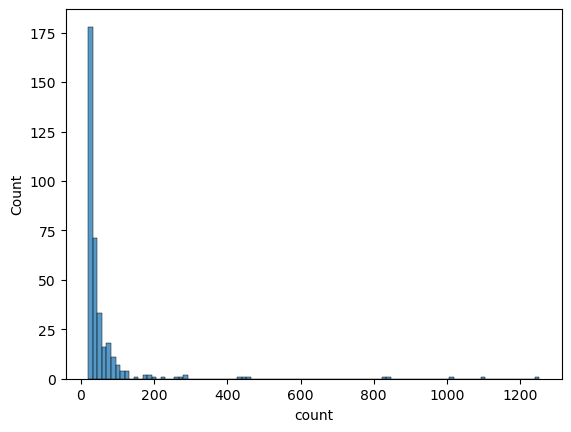

In [8]:
sns.histplot(new_df[new_df['count'] > 20], x="count", bins=100)

In [9]:
new_df['count'].head()

0    1252
1    1092
2    1011
3     840
4     833
Name: count, dtype: int64